<a href="https://colab.research.google.com/github/nitik1998/GENIE_DiffusionLearning/blob/main/notebooks/Task2_Graph_Classifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# GENIE Task 2 GNN

This notebook is the mentor-facing Colab wrapper for the graph-first Task 2 pipeline.
It uses `src/task2_gnn.py` as the source of truth and does not reimplement the GNN inside the notebook.

Active detector channel order: `Tracks`, `ECAL`, `HCAL`.
Task 2 is the strongest section because sparse detector hits are represented as graphs rather than generic dense images.
Use `RUN_MODE = "sanity"` for a short 10-epoch check or `RUN_MODE = "full"` for the final long run.


In [37]:
# 1. Optional Google Drive mount
from pathlib import Path

USE_GOOGLE_DRIVE = True
DRIVE_MOUNT_POINT = Path('/content/drive')

if USE_GOOGLE_DRIVE:
    try:
        from google.colab import drive
        drive.mount(str(DRIVE_MOUNT_POINT))
        print(f'Mounted Google Drive at {DRIVE_MOUNT_POINT}')
    except ImportError:
        print('google.colab is not available in this environment.')
else:
    print('Skipping Google Drive mount.')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Mounted Google Drive at /content/drive


In [38]:
# 2. Clone repo and install dependencies
from pathlib import Path
import os
import subprocess
import sys

REPO_URL = 'https://github.com/nitik1998/GENIE_DiffusionLearning.git'
REPO_DIR = Path('/content/GENIE_DiffusionLearning')

if not REPO_DIR.exists():
    subprocess.run(['git', 'clone', REPO_URL, str(REPO_DIR)], check=True)

os.chdir(REPO_DIR)
subprocess.run(['git', 'fetch', 'origin'], check=True)
subprocess.run(['git', 'reset', '--hard', 'origin/main'], check=True)

if str(REPO_DIR) not in sys.path:
    sys.path.insert(0, str(REPO_DIR))

subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', '-r', 'requirements.txt'], check=True)
print(f'Repo ready at: {REPO_DIR}')
print(subprocess.check_output(['git', 'rev-parse', '--short', 'HEAD'], text=True).strip())


Repo ready at: /content/GENIE_DiffusionLearning
1ee64e7


In [43]:
# 3. Imports and runtime config
from pathlib import Path
import argparse
import json
import os
import random
import shutil
import shlex
import subprocess
import sys
import time

import matplotlib.pyplot as plt
import numpy as np
import torch
from IPython.display import Image, Markdown, display

from src.config import CHANNEL_NAMES, get_auto_batch_size
from src.data_utils import load_dataset, image_to_pointcloud
from src.task2_gnn import main as task2_main

SEED = 42
FORCE_RERUN = True
RUN_MODE = "full"  # change to "full" for the final submission run
SANITY_EPOCHS = 10
FULL_EPOCHS = 30

BASE_TASK_CONFIG = {
    'base_exp_name': 'task2_graph_classifier',
    'display_name': 'Task 2 Graph Classifier Run',
    'batch_size': 0,
    'max_events': None,
    'knn_k': 8,
    'model_type': 'graphsage',
    'hidden_dim': 64,
    'dropout': 0.4,
}

def detect_vram_gb():
    if not torch.cuda.is_available():
        return 0.0
    return torch.cuda.get_device_properties(0).total_memory / (1024 ** 3)

def choose_batch_size(task_num, requested_batch_size):
    if requested_batch_size and requested_batch_size > 0:
        return int(requested_batch_size)
    return int(get_auto_batch_size(task_num))

TASK_CONFIG = dict(BASE_TASK_CONFIG)
TASK_CONFIG["epochs"] = SANITY_EPOCHS if RUN_MODE == "sanity" else FULL_EPOCHS
TASK_CONFIG["max_events"] = 20000 if RUN_MODE == "sanity" else BASE_TASK_CONFIG["max_events"]
TASK_CONFIG['exp_name'] = f"{BASE_TASK_CONFIG['base_exp_name']}_sanity" if RUN_MODE == 'sanity' else BASE_TASK_CONFIG['base_exp_name']
TASK_CONFIG['batch_size'] = choose_batch_size(task_num=2, requested_batch_size=BASE_TASK_CONFIG['batch_size'])
TASK_CONFIG['vram_gb'] = round(detect_vram_gb(), 1)

DATASET_SOURCE = Path('/content/drive/MyDrive/quark-gluon_data-set_n139306.hdf5')
if not DATASET_SOURCE.exists():
    DATASET_SOURCE = Path('/content/quark-gluon_data-set_n139306.hdf5')

RESULTS_ROOT = Path('/content/results_colab')
CHECKPOINT_ROOT = RESULTS_ROOT / 'checkpoints'
DATA_DIR = REPO_DIR / 'data'
DATASET_TARGET = DATA_DIR / 'quark-gluon_data-set_n139306.hdf5'
FINAL_RESULTS_DIR = RESULTS_ROOT / 'task2' / TASK_CONFIG['exp_name']

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DATA_DIR.mkdir(parents=True, exist_ok=True)
for path in [RESULTS_ROOT, CHECKPOINT_ROOT, FINAL_RESULTS_DIR]:
    path.mkdir(parents=True, exist_ok=True)

if DATASET_SOURCE.exists() and DATASET_SOURCE.resolve() != DATASET_TARGET.resolve():
    shutil.copy2(DATASET_SOURCE, DATASET_TARGET)
elif not DATASET_TARGET.exists():
    raise FileNotFoundError(f"Dataset not found at {DATASET_SOURCE} or {DATASET_TARGET}")

os.environ['GENIE_PROJECT_ROOT'] = str(REPO_DIR)
os.environ['GENIE_DATA_DIR'] = str(DATA_DIR)
os.environ['GENIE_OUTPUT_DIR'] = str(RESULTS_ROOT)
os.environ['GENIE_CHECKPOINT_DIR'] = str(CHECKPOINT_ROOT)

print(f"Python executable: {sys.executable}")
print(f"GPU available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU device: {torch.cuda.get_device_name(0)}")
    print(f"GPU VRAM (GB): {TASK_CONFIG['vram_gb']}")
print(f"Run mode: {RUN_MODE}")
print(f"Active experiment: {TASK_CONFIG['exp_name']} ({TASK_CONFIG['display_name']})")
print(f"Selected batch size: {TASK_CONFIG['batch_size']}")
print('The official script runs directly below, so epoch logs should appear in this cell output.')
print('Estimate remaining time after the first epoch: epoch_time * remaining_epochs.')

def show_png(path, width=900):
    path = Path(path)
    if path.exists():
        display(Image(filename=str(path), width=width))
    else:
        print(f'Missing image: {path}')

def print_metrics(path, title):
    path = Path(path)
    if not path.exists():
        print(f'Missing metrics file: {path}')
        return
    payload = json.loads(path.read_text())
    metrics = payload.get('metrics', payload)
    display(Markdown(f'### {title}'))
    for key, value in metrics.items():
        print(f'{key}: {value}')


Python executable: /usr/bin/python3
GPU available: True
GPU device: NVIDIA A100-SXM4-80GB
GPU VRAM (GB): 79.3
Run mode: full
Active experiment: task2_graph_classifier (Task 2 Graph Classifier Run)
Selected batch size: 512
The official script runs directly below, so epoch logs should appear in this cell output.
Estimate remaining time after the first epoch: epoch_time * remaining_epochs.


Loaded shape: (256, 3, 125, 125)
Labels shape: (256,)
Channel names: ('Tracks', 'ECAL', 'HCAL')
Class distribution: {0: 121, 1: 135}


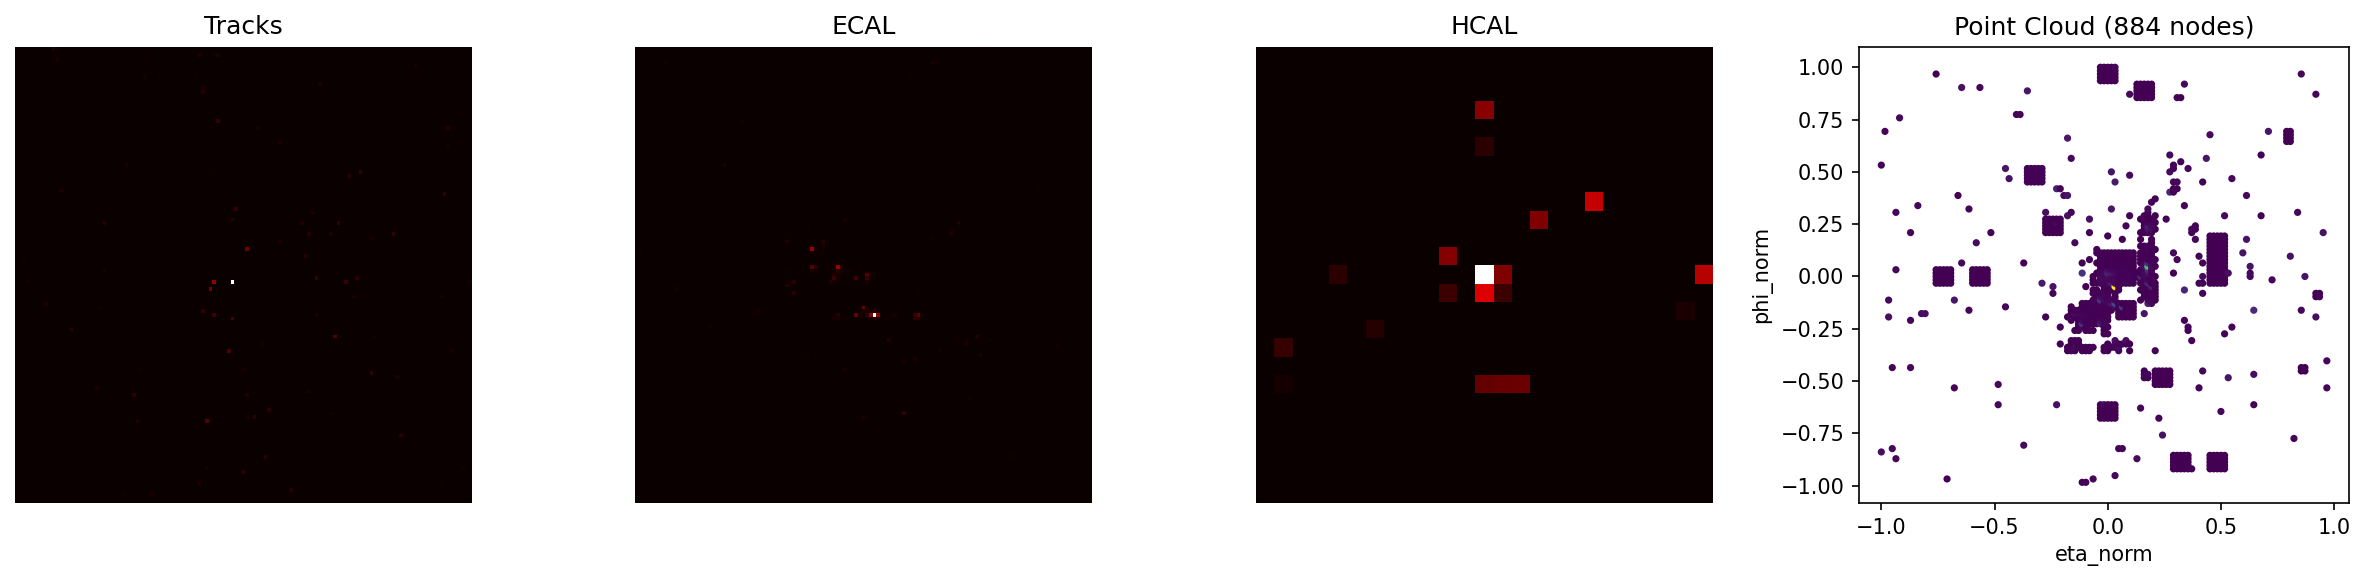

Saved preview to: /content/results_colab/task2/task2_graph_classifier_sanity/task2_input_sanity_check.png


In [40]:
# 4. Data sanity check
sanity_events = 256 if TASK_CONFIG['max_events'] is None else min(TASK_CONFIG['max_events'], 256)
X, y = load_dataset(str(DATA_DIR), max_events=sanity_events)
print('Loaded shape:', X.shape)
print('Labels shape:', y.shape)
print('Channel names:', CHANNEL_NAMES)
unique, counts = np.unique(y, return_counts=True)
print('Class distribution:', dict(zip(unique.tolist(), counts.tolist())))

sample = X[0]
points = image_to_pointcloud(sample)
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ch in range(3):
    vmax = max(float(sample[ch].max()), 1e-6)
    axes[ch].imshow(sample[ch], cmap='hot', vmin=0, vmax=vmax)
    axes[ch].set_title(CHANNEL_NAMES[ch])
    axes[ch].axis('off')
axes[3].scatter(points[:, 0], points[:, 1], s=6, c=np.sum(points[:, 2:], axis=1), cmap='viridis')
axes[3].set_title(f'Point Cloud ({len(points)} nodes)')
axes[3].set_xlabel('eta_norm')
axes[3].set_ylabel('phi_norm')
plt.tight_layout()
preview_path = FINAL_RESULTS_DIR / 'task2_input_sanity_check.png'
fig.savefig(preview_path, dpi=150, bbox_inches='tight')
display(Image(filename=str(preview_path), width=1200))
plt.close(fig)
print(f'Saved preview to: {preview_path}')


In [44]:
# 5. Final Task 2 config
display(Markdown(f"## Active Config: `{TASK_CONFIG['exp_name']}`"))
for key, value in TASK_CONFIG.items():
    print(f'{key}: {value}')


## Active Config: `task2_graph_classifier`

base_exp_name: task2_graph_classifier
display_name: Task 2 Graph Classifier Run
batch_size: 512
max_events: None
knn_k: 8
model_type: graphsage
hidden_dim: 64
dropout: 0.4
epochs: 30
exp_name: task2_graph_classifier
vram_gb: 79.3


In [45]:
# 6. Run Task 2 through the official script with live Colab logs
cmd = [
    sys.executable,
    '-u',
    'src/task2_gnn.py',
    '--exp-name', TASK_CONFIG['exp_name'],
    '--epochs', str(TASK_CONFIG['epochs']),
    '--batch-size', str(TASK_CONFIG['batch_size']),
    '--knn-k', str(TASK_CONFIG['knn_k']),
    '--model-type', TASK_CONFIG['model_type'],
    '--hidden-dim', str(TASK_CONFIG['hidden_dim']),
    '--dropout', str(TASK_CONFIG['dropout']),
    '--seed', str(SEED),
]
if FORCE_RERUN:
    cmd.append('--force-rerun')
if TASK_CONFIG.get('max_events') is not None:
    cmd += ['--max-events', str(TASK_CONFIG['max_events'])]

cmd_str = ' '.join(shlex.quote(part) for part in cmd)
print(f'Running: {cmd_str}')
print('Epoch logs should stream live below. Use the first completed epoch to estimate remaining time.')
start_time = time.time()

# Use Popen for live streaming so tqdm progress bars are visible
env = {**os.environ, 'PYTHONUNBUFFERED': '1'}
proc = subprocess.Popen(cmd, stdout=subprocess.PIPE, stderr=subprocess.STDOUT,
                        env=env, bufsize=1, universal_newlines=True)
for line in proc.stdout:
    print(line, end='', flush=True)
proc.wait()

elapsed = time.time() - start_time
if proc.returncode != 0:
    raise RuntimeError(f'Task 2 command failed with exit code {proc.returncode}')
print(f"Task 2 run finished in {elapsed / 60:.1f} minutes")


Running: /usr/bin/python3 -u src/task2_gnn.py --exp-name task2_graph_classifier --epochs 30 --batch-size 512 --knn-k 8 --model-type graphsage --hidden-dim 64 --dropout 0.4 --seed 42 --force-rerun
Epoch logs should stream live below. Use the first completed epoch to estimate remaining time.
[2026-03-30 04:43:35] [INFO] src.config — GPU detected: NVIDIA A100-SXM4-80GB (79.3 GB VRAM)
[2026-03-30 04:43:35] [INFO] task2 — Experiment: task2_graph_classifier → /content/results_colab/task2/task2_graph_classifier
[2026-03-30 04:43:35] [INFO] src.data_utils — Loading dataset from: /content/GENIE_DiffusionLearning/data/quark-gluon_data-set_n139306.hdf5
[2026-03-30 04:45:21] [INFO] src.data_utils — Loaded 139,306 events — shape (139306, 3, 125, 125) | quark=69,653, gluon=69,653
[2026-03-30 04:45:21] [INFO] src.data_utils — Split — train: 97,514 | val: 20,895 | test: 20,897
[2026-03-30 04:45:26] [INFO] task2 — Pre-building train graph dataset (n=97,514, k=8)...
  Building train graphs: 0/97514...
 

## Final Outputs: `task2_graph_classifier`

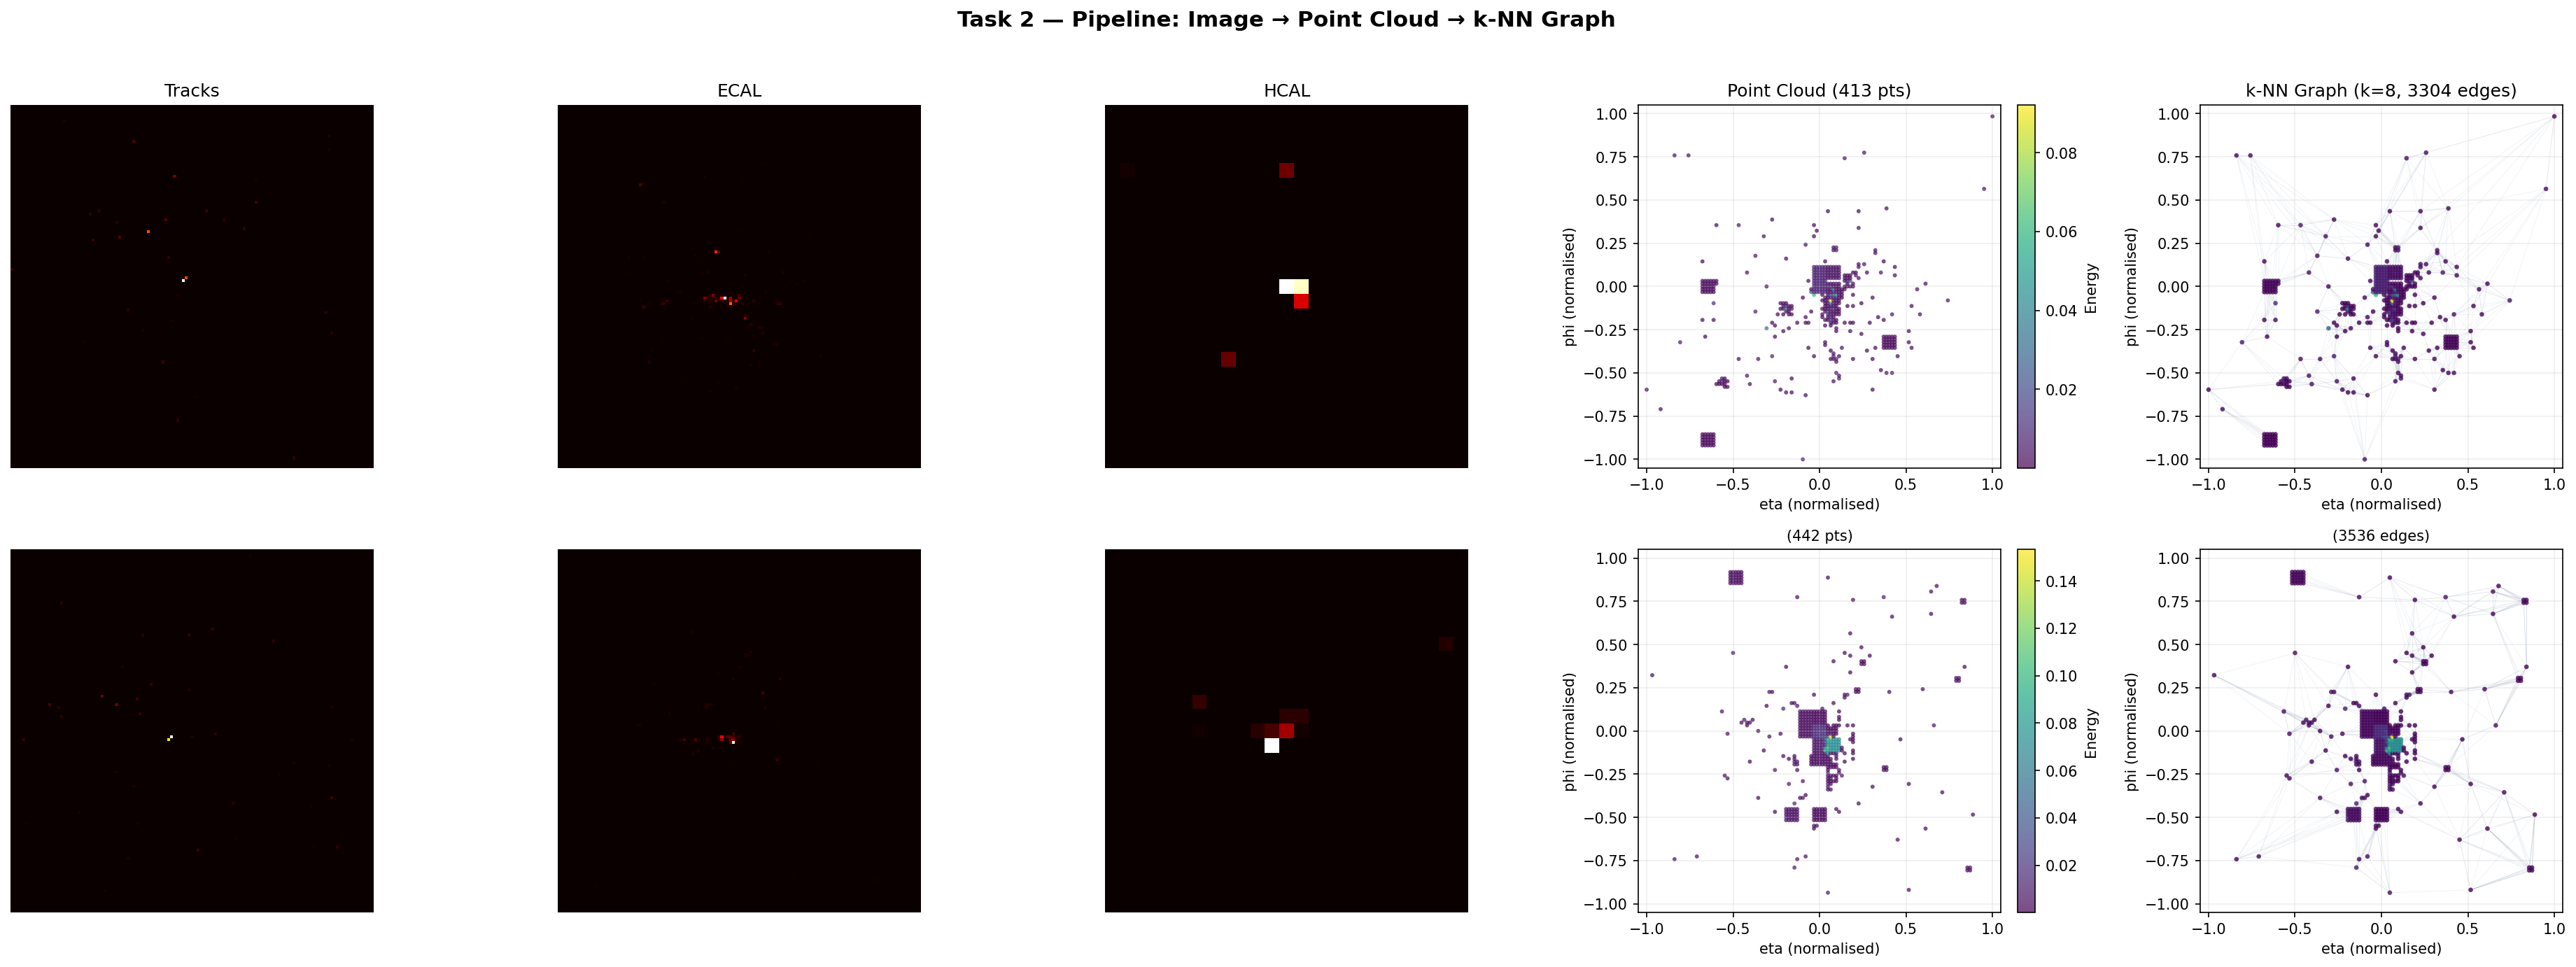

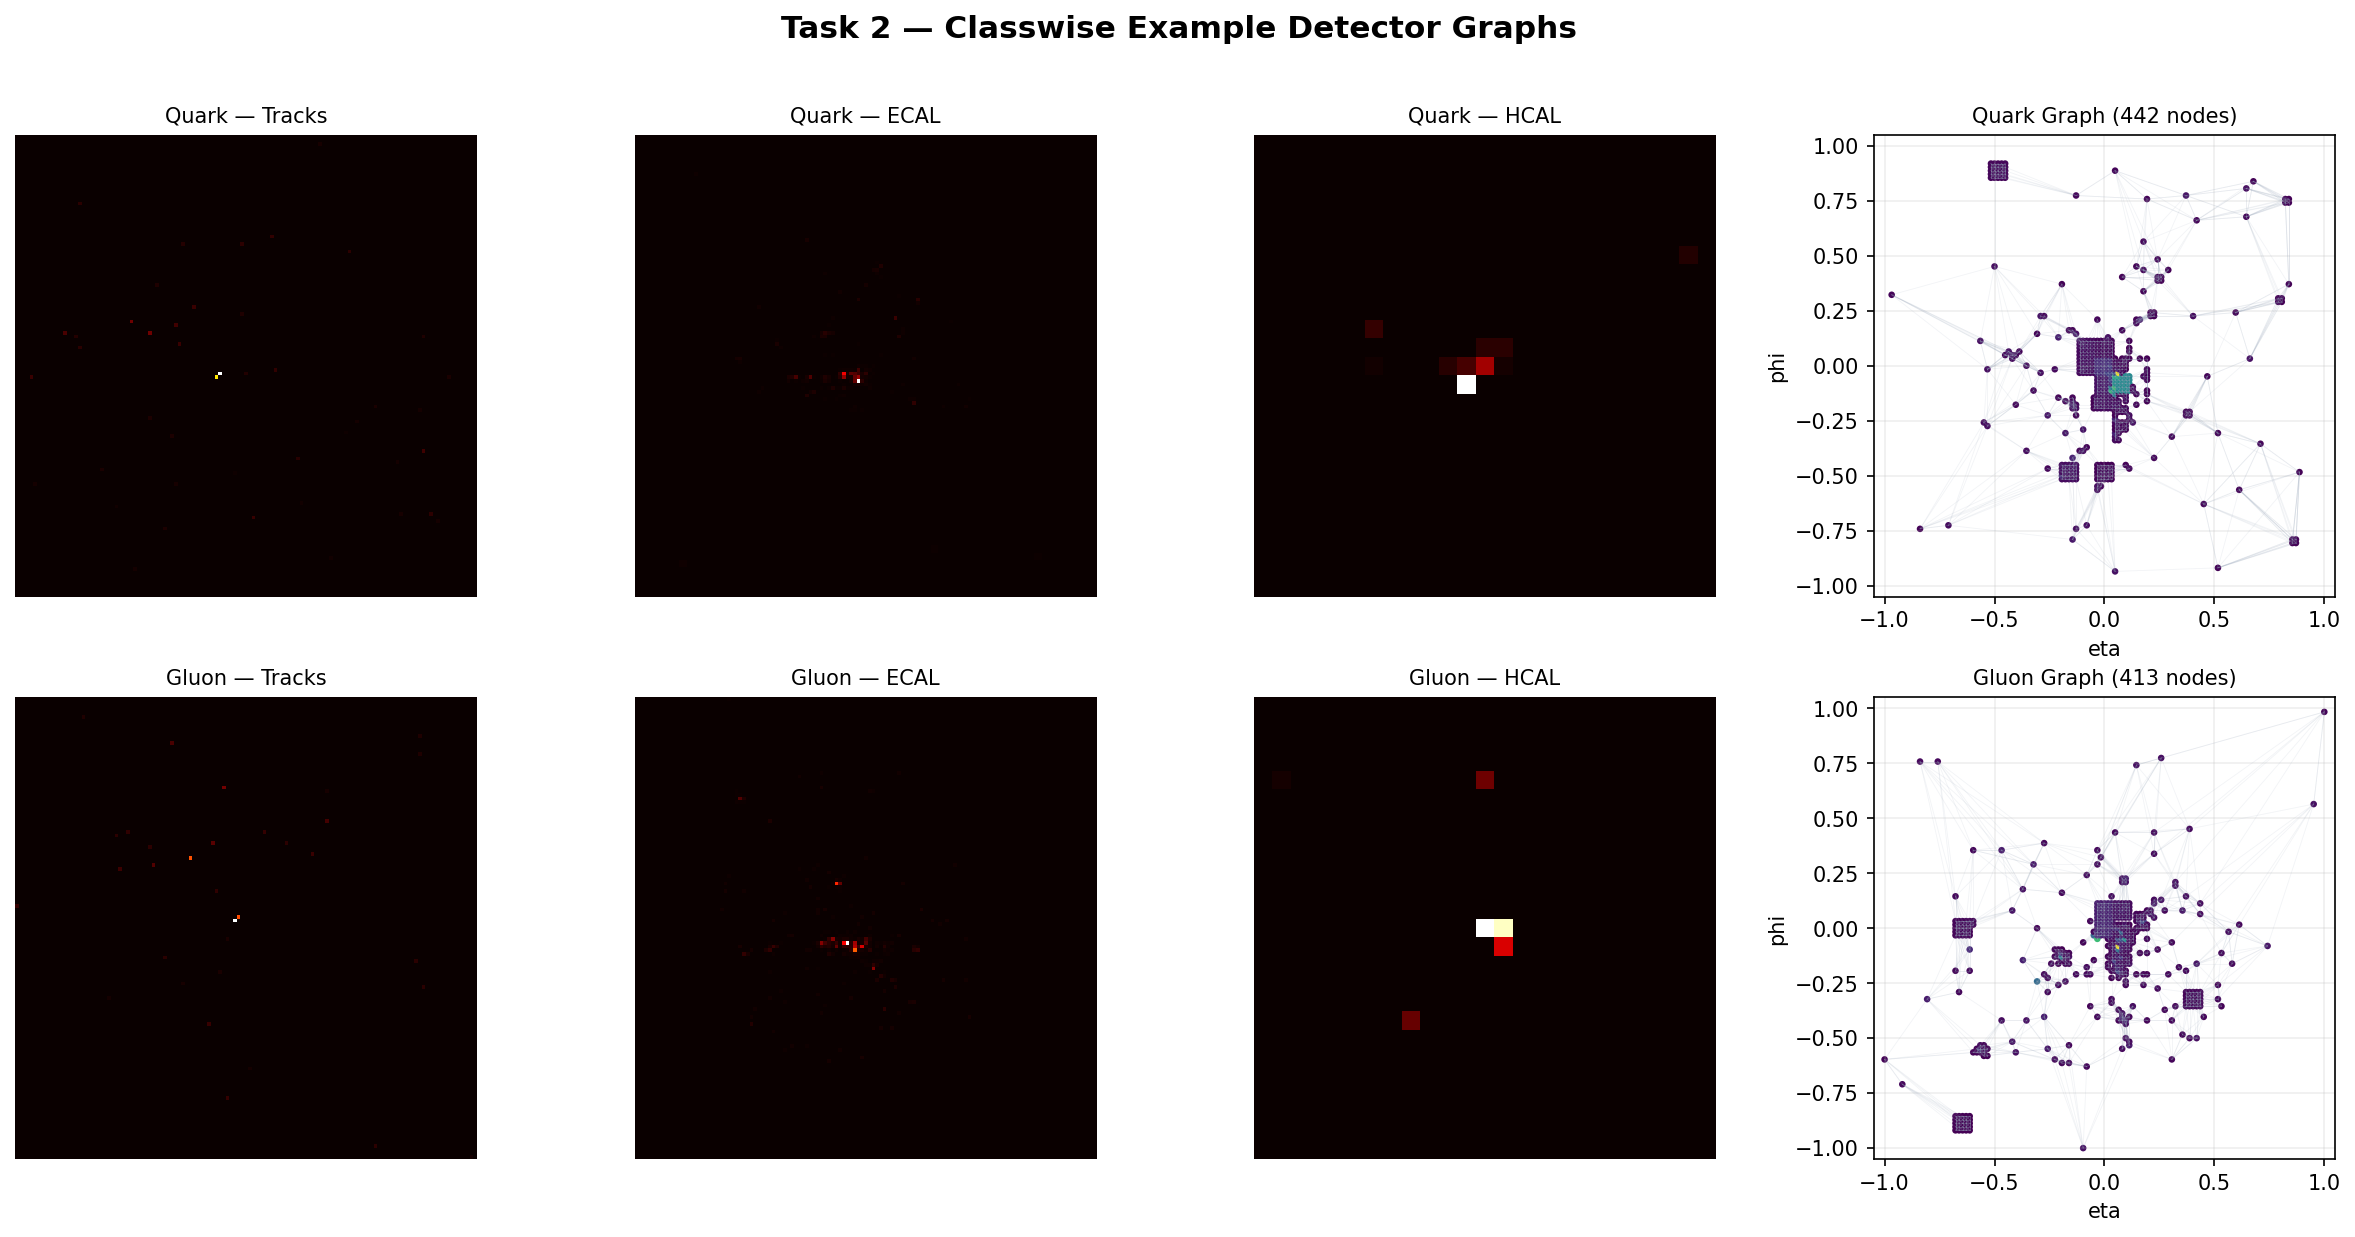

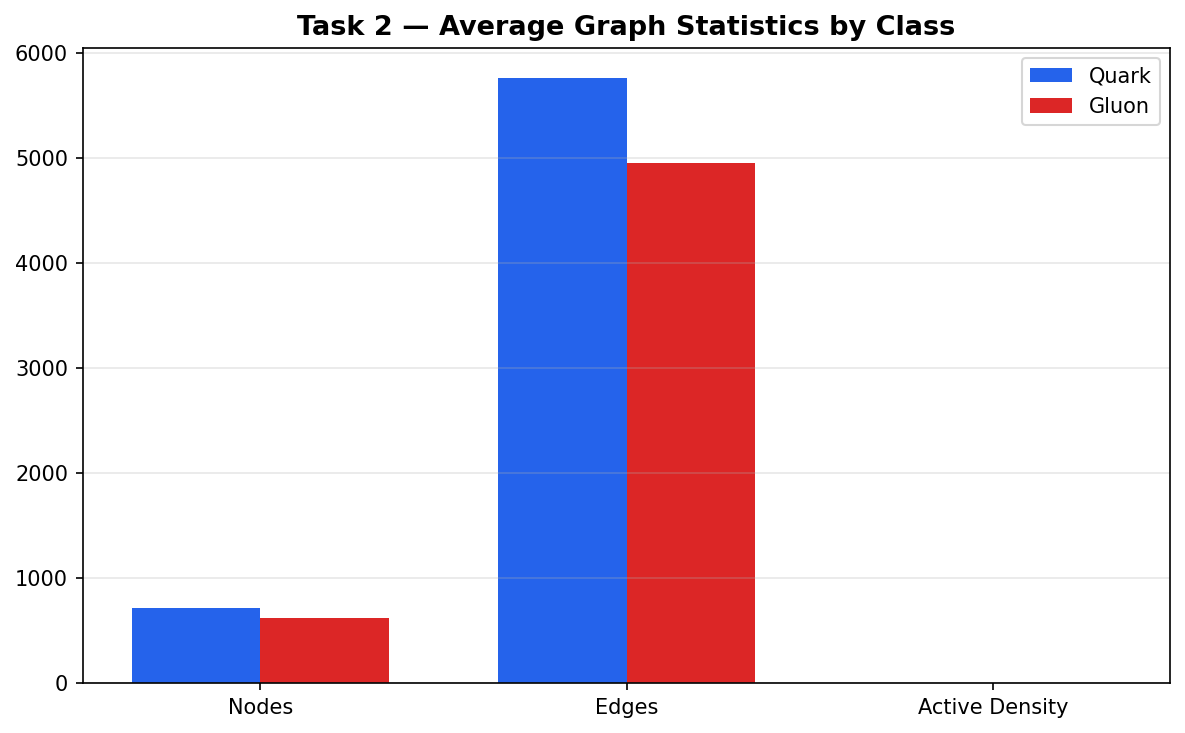

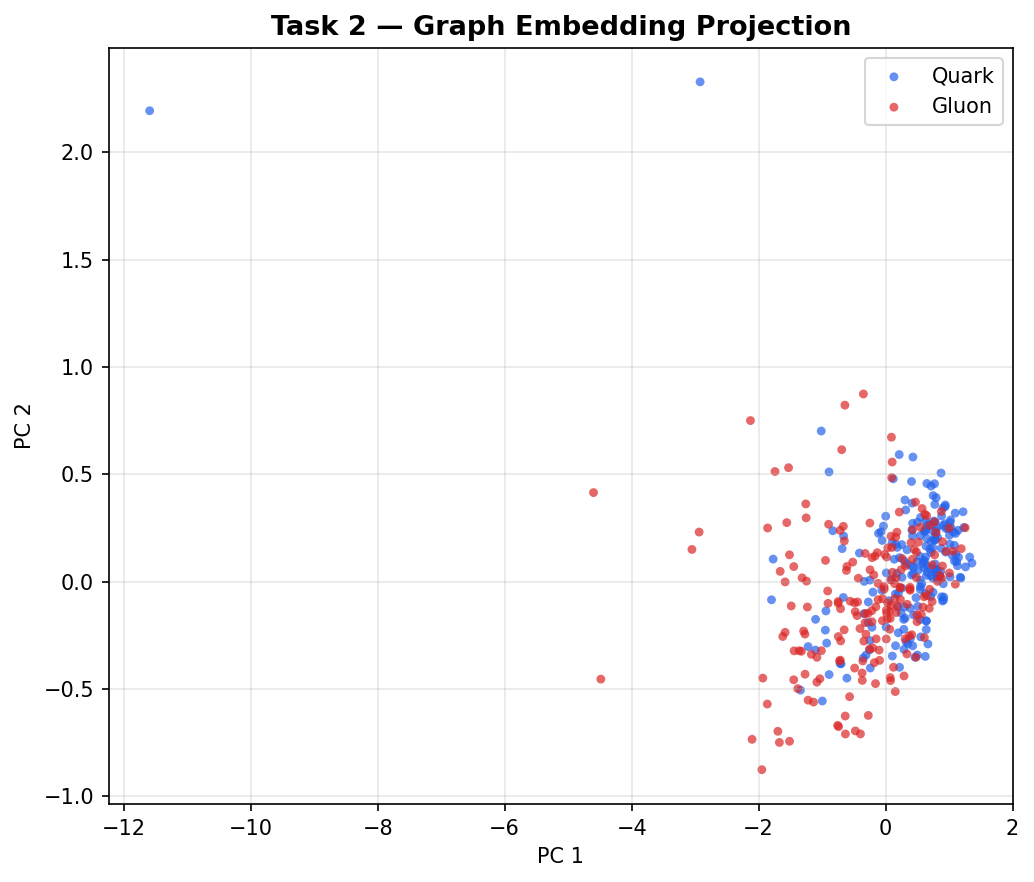

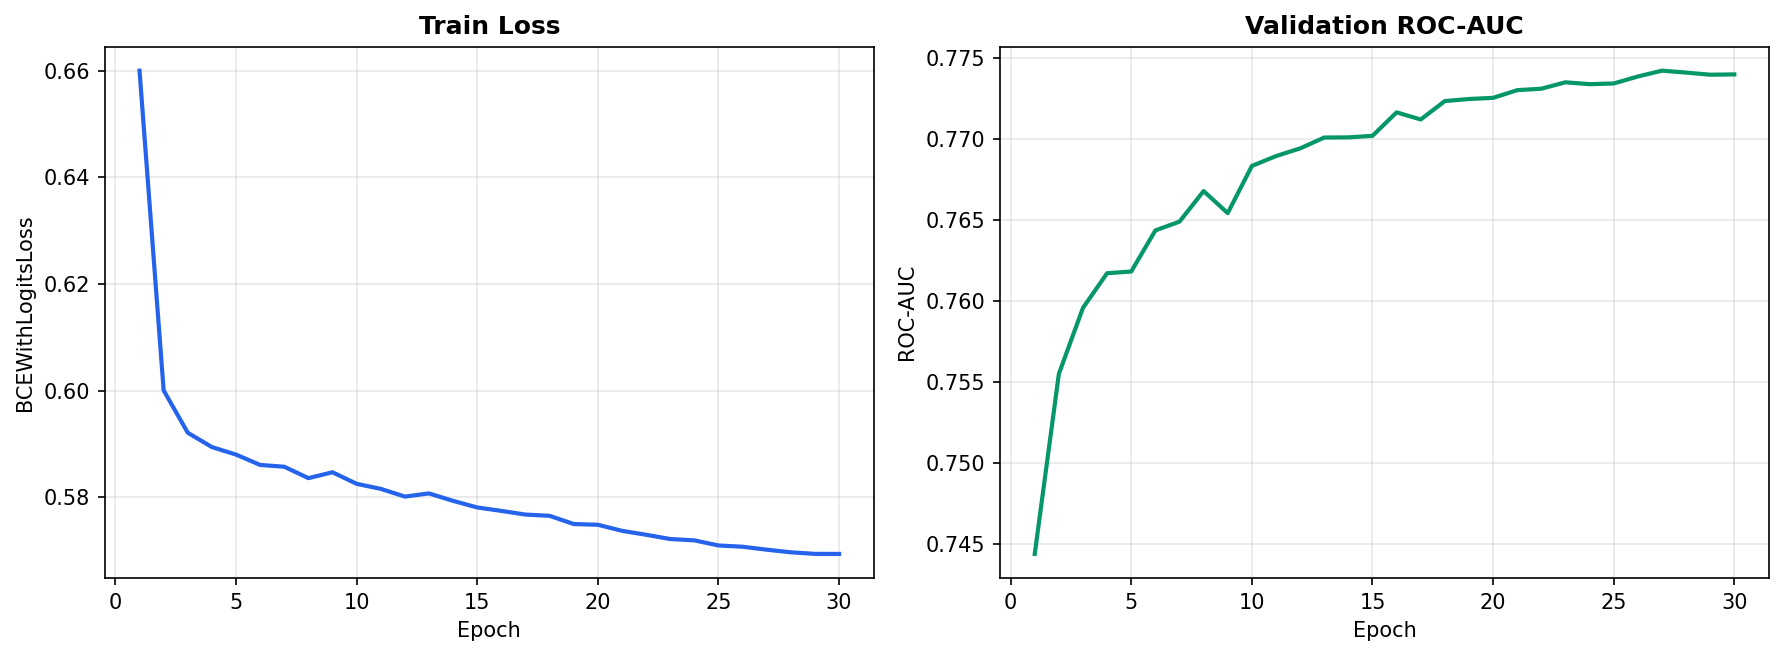

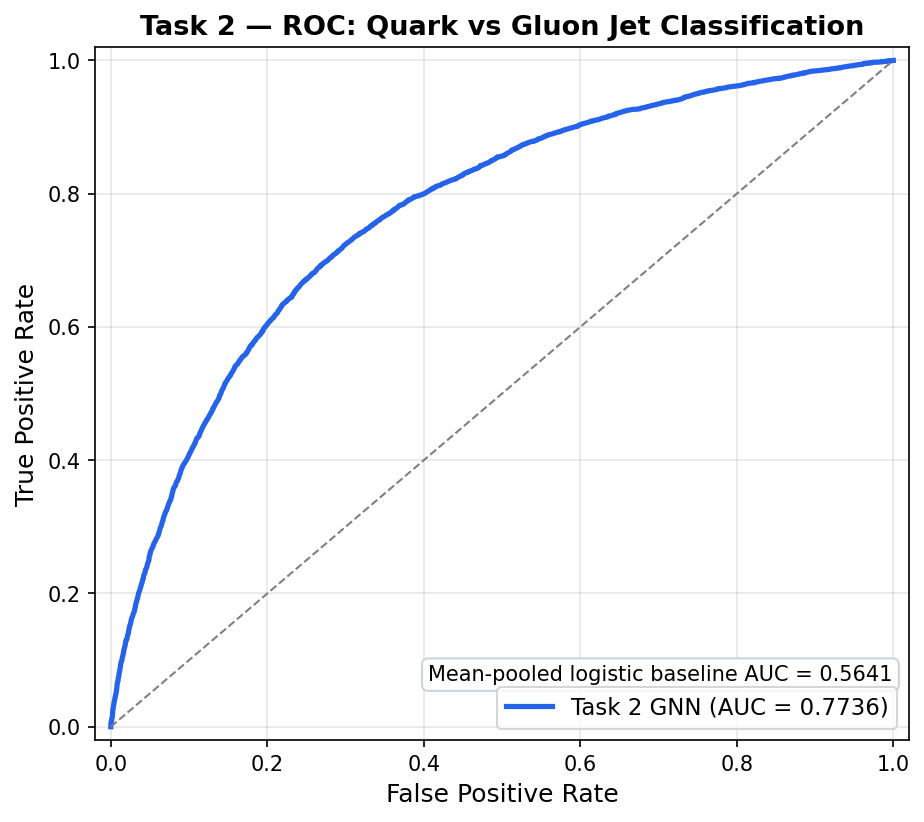

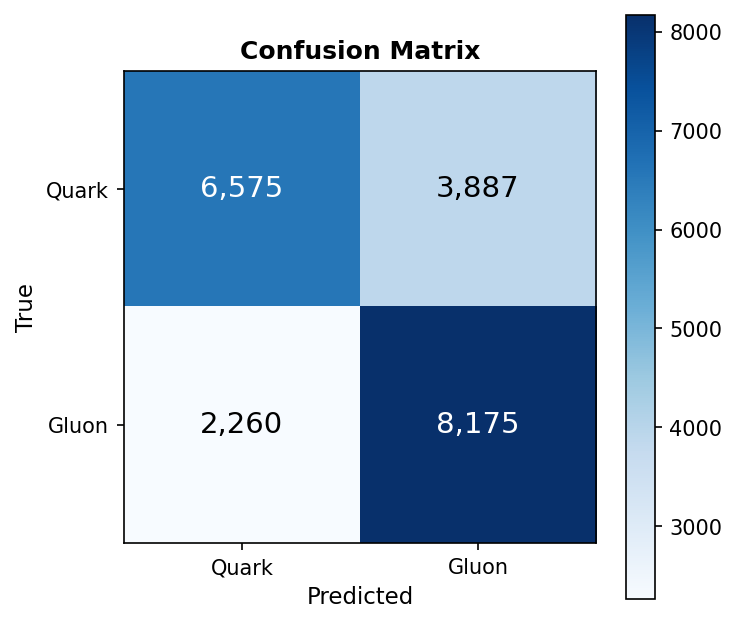

### Task 2 Metrics

roc_auc: 0.7735939187862855
accuracy: 0.7058429439632483
f1: 0.7267635684757968
baseline_val_auc: 0.5797472457453707
baseline_test_auc: 0.564052742226253
baseline_test_accuracy: 0.5427573335885534
baseline_test_f1: 0.5621190596214656


In [46]:
# 7. Visualize final outputs inline
display(Markdown(f"## Final Outputs: `{TASK_CONFIG['exp_name']}`"))
show_png(FINAL_RESULTS_DIR / 'image_to_pointcloud_graph_pipeline.png', width=1200)
show_png(FINAL_RESULTS_DIR / 'classwise_example_graphs.png', width=1200)
show_png(FINAL_RESULTS_DIR / 'graph_stats_by_class.png', width=900)
show_png(FINAL_RESULTS_DIR / 'graph_embedding_projection.png', width=900)
show_png(FINAL_RESULTS_DIR / 'training_curves.png', width=900)
show_png(FINAL_RESULTS_DIR / 'roc_curve.png', width=900)
show_png(FINAL_RESULTS_DIR / 'confusion_matrix.png', width=800)
print_metrics(FINAL_RESULTS_DIR / 'metrics.json', 'Task 2 Metrics')


In [47]:
# 8. Package artifacts for download
archive_base = RESULTS_ROOT / TASK_CONFIG['exp_name']
archive_path = shutil.make_archive(str(archive_base), 'zip', root_dir=str(FINAL_RESULTS_DIR.parent), base_dir=FINAL_RESULTS_DIR.name)
print(f'Created archive: {archive_path}')

try:
    from google.colab import files
    files.download(archive_path)
except Exception as exc:
    print(f'Automatic download skipped: {exc}')


Created archive: /content/results_colab/task2_graph_classifier.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>